In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn import metrics

In [2]:
df = pd.read_csv('diabetes.csv')

In [3]:
df.head()

,pr,glucose,bp_diastolic,skin_triceps,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

In [5]:
df.columns

Index(['pr', 'glucose', 'bp_diastolic', 'skin_triceps', 'insulin', 'bmi',
       'pedigree', 'age', 'label'],
      dtype='object')

In [6]:
df.rename(columns = {"label" : "is_diabetic"}, inplace=True)

In [7]:
df.columns

Index(['pr', 'glucose', 'bp_diastolic', 'skin_triceps', 'insulin', 'bmi',
       'pedigree', 'age', 'is_diabetic'],
      dtype='object')

In [8]:
df.isnull().sum()

,0
pr,0
glucose,0
bp_diastolic,0
skin_triceps,0
insulin,0
bmi,0
pedigree,0
age,0
is_diabetic,0


There is no null value in the dataset.

In [9]:
X = df.drop(columns="glucose", axis=1)
y = df["glucose"]

In [10]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [11]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

## Model 1: Multiple Linear Regression (All Features)

In [12]:
rgsr = LinearRegression()
model = rgsr.fit(x_train_scaled, y_train)

In [13]:
y_pred = model.predict(x_test_scaled)

In [14]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [15]:
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")

Mean Absolute Error: 20.548453668839127
Mean Squared Error: 693.8724929223761
Root Mean Squared Error: 26.341459582232265
R-squared: 0.28280468810375103


In [16]:
model.score(x_test_scaled, y_test)

0.28280468810375103

In [17]:
df_1 = pd.DataFrame({"Actual_glucose":y_test, "Predicted_glucose":y_pred})
df_1.head()

,Actual_glucose,Predicted_glucose
668,98,119.913037
324,112,95.703254
624,108,104.639623
690,107,114.050402
473,136,118.583217


<Axes: >

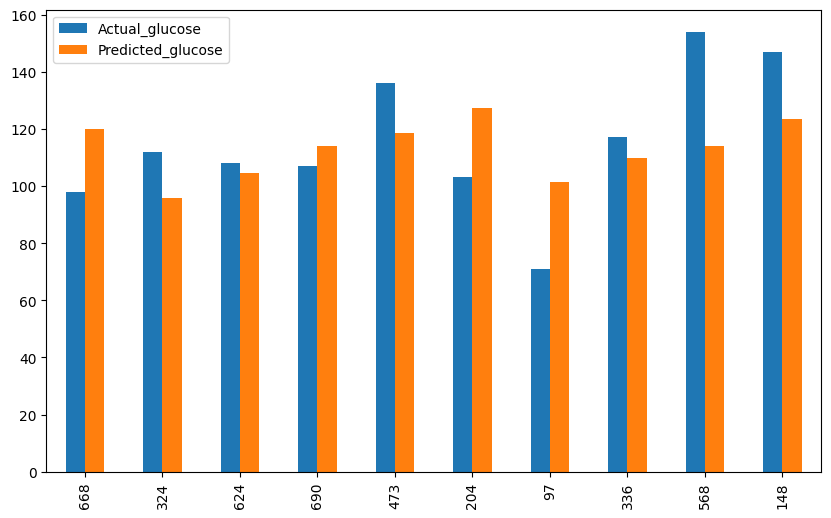

In [18]:
df_1.head(10).plot(kind="bar", figsize=(10, 6))

## Visualization

In [19]:
pip install yellowbrick

In [20]:
from yellowbrick.regressor import PredictionError
visualizer = PredictionError(rgsr)

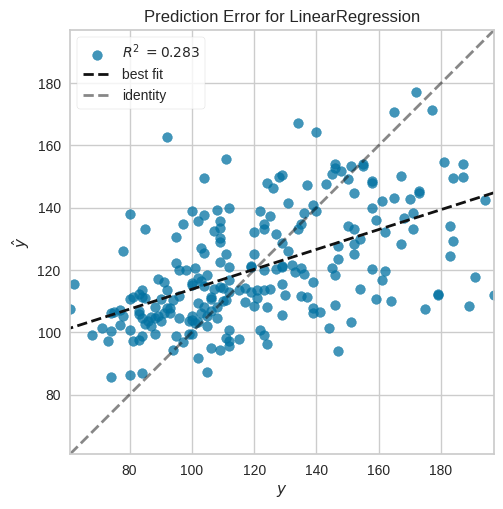

<Axes: title={'center': 'Prediction Error for LinearRegression'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [21]:
visualizer.fit(x_train_scaled, y_train)
visualizer.score(x_test_scaled, y_test)

visualizer.show()

## Feature Selection

In [22]:
from sklearn.feature_selection import SequentialFeatureSelector as sfs

In [23]:
selector = sfs(rgsr, n_features_to_select=5, direction="backward")
selector = selector.fit(x_train_scaled, y_train)

selected_features = list(X.columns[selector.get_support()])
print(selected_features)

['bp_diastolic', 'skin_triceps', 'insulin', 'age', 'is_diabetic']


In [24]:
selector.get_support()

array([False,  True,  True,  True, False, False,  True,  True])

In [25]:
x_train_selected = x_train[selected_features]
x_test_selected = x_test[selected_features]

In [26]:
scaler_new = StandardScaler()
x_train_sel_scaled = scaler_new.fit_transform(x_train_selected)
x_test_sel_scaled = scaler_new.transform(x_test_selected)

In [27]:
model = rgsr.fit(x_train_sel_scaled, y_train)
y_pred_sfs = model.predict(x_test_sel_scaled)

In [28]:
mae = mean_absolute_error(y_test, y_pred_sfs)
mse = mean_squared_error(y_test, y_pred_sfs)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_sfs)

In [29]:
print(f"Slected Features: {selected_features}")
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")

Slected Features: ['bp_diastolic', 'skin_triceps', 'insulin', 'age', 'is_diabetic']
Mean Absolute Error: 20.59250459648363
Mean Squared Error: 681.9019640622952
Root Mean Squared Error: 26.11325265190637
R-squared: 0.29517757687933943


It should be generalize to make good score.
Use for loop

This shows that the variable glucose is not linearly correlated with other features.

In [30]:
corr = df.corr()

<Axes: >

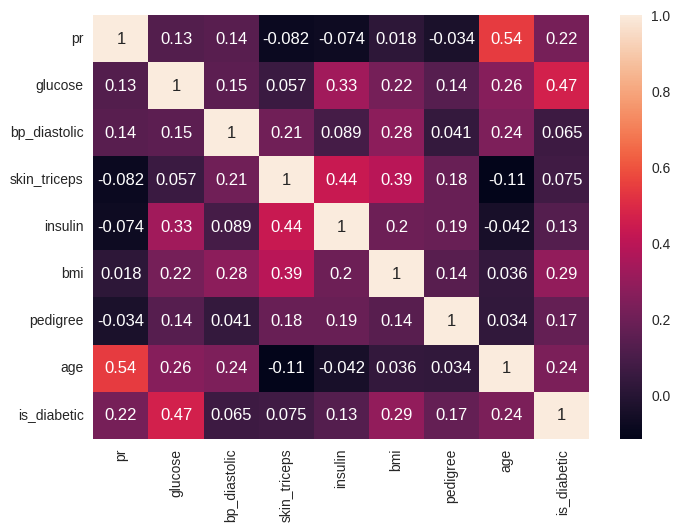

In [31]:
sns.heatmap(corr, annot=True)

In [32]:
df_p = pd.DataFrame({"Actual_glucose":y_test, "Predicted_glucose":y_pred_sfs})
df_p.head()

,Actual_glucose,Predicted_glucose
668,98,119.705132
324,112,97.065204
624,108,104.874844
690,107,111.992960
473,136,119.085349


<Axes: >

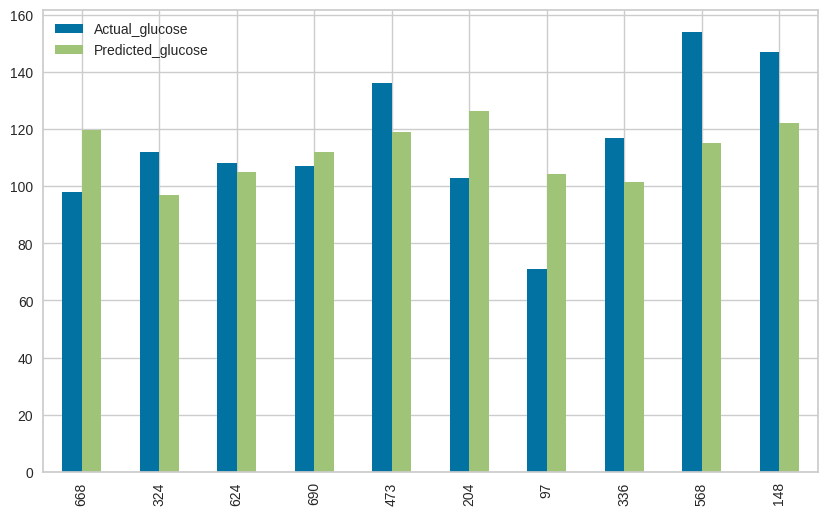

In [33]:
df_p.head(10).plot(kind="bar", figsize=(10, 6))


## Gradient Descent Method

I am using 1 independent variable for gradient descent.

In [34]:
X = df[["bp_diastolic"]]
y = df["glucose"]

In [35]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [36]:
b0 = 0.0 # Intercept
b1 = 0.0 # Slope
learning_rate = 0.0000001 # Small alpha because SAT scores are large
epochs = 1000 # Number of iterations
n = float(len(x_train))

In [37]:
x_vals = x_train.to_numpy().flatten()
y_vals = y_train.to_numpy()

In [38]:
for i in range(epochs):
 # Current prediction
 y_current = b1 * x_vals + b0

 # Calculate Gradients (Partial Derivatives)
 # D_b1 = -2/n * sum(x * (y_actual - y_predicted))
 # D_b0 = -2/n * sum(y_actual - y_predicted)
 D_b1 = (-2/n) * sum(x_vals * (y_vals - y_current))
 D_b0 = (-2/n) * sum(y_vals - y_current)

 # Update parameters
 b1 = b1 - learning_rate * D_b1
 b0 = b0 - learning_rate * D_b0
print(f"Final intercept (b0): {b0}")
print(f"Final slope (b1): {b1}")

Final intercept (b0): 0.015526000287472207
Final slope (b1): 1.0609917032751652


In [39]:
y_pred_gd = b1 * x_test.to_numpy().flatten() + b0


In [40]:
print('--- Gradient Descent Evaluation ---')
print("MAE:\t", metrics.mean_absolute_error(y_test, y_pred_gd))
print("MSE:\t", metrics.mean_squared_error(y_test, y_pred_gd))
print("RMSE:\t", np.sqrt(metrics.mean_squared_error(y_test, y_pred_gd)))
print("R-Squared:", metrics.r2_score(y_test, y_pred_gd))

--- Gradient Descent Evaluation ---
MAE:	 50.029297704953414
MSE:	 3737.244063591528
RMSE:	 61.13300306374232
R-Squared: -2.862862340213537


The negative R_squared value shows that the data is actually worse fit for variable bp_diastolic. It is obvious because when trained all features, the score was only 0.29. So, the actually all fearture are non-linear with column "glucose".

<Axes: title={'center': 'Manual Gradient Descent vs Actual'}>

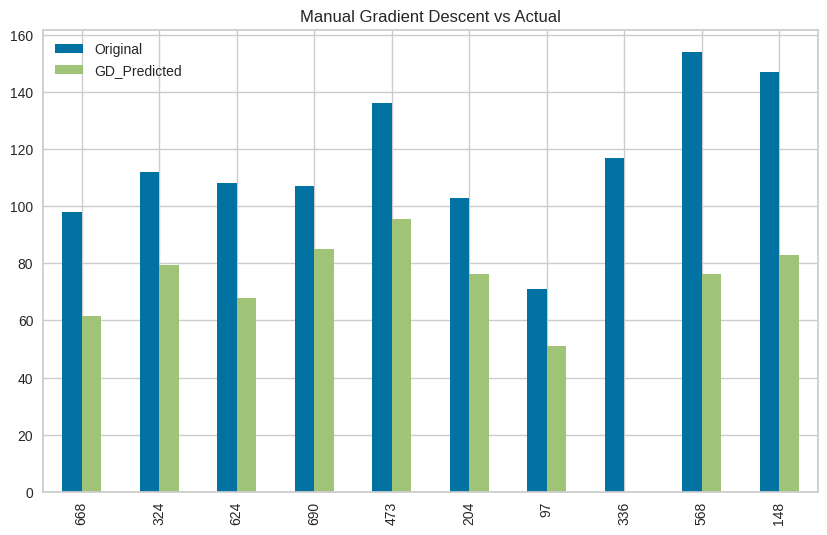

In [41]:
y_comparison = pd.DataFrame({'Original': y_test, 'GD_Predicted': y_pred_gd})
y_comparison.head(10).plot(kind="bar", figsize=(10, 6), title="Manual Gradient Descent vs Actual")